In [1]:
# https://platform.olimpiada-ai.ro/en/problems/222

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch
from torch import nn
import torch.nn.functional as F
from PIL import Image
import io
from IPython.display import clear_output

In [2]:
train = pd.read_csv('/kaggle/input/datasets/abukanabek/sleeping-sheriff/train.csv')
test = pd.read_csv('/kaggle/input/datasets/abukanabek/sleeping-sheriff/test.csv')
candidates = pd.read_csv('/kaggle/input/datasets/abukanabek/sleeping-sheriff/candidates.csv')

train.shape, test.shape, candidates.shape

((15715, 3), (2621, 2), (500, 2))

In [3]:
train.head()

,id,coords,text
0,0,|1.093462|0.098401|1.122740|0.020423|1.097495|...,"I used to pretend to believe in God. Mainly, I..."
1,0,|1.048931|-0.085245|1.094816|-0.103772|1.12495...,"I used to pretend to believe in God. Mainly, I..."
2,0,|0.793060|0.016275|0.806455|-0.043401|0.878194...,"I used to pretend to believe in God. Mainly, I..."
3,0,|1.064846|-0.023528|1.056215|0.040268|1.064306...,"I used to pretend to believe in God. Mainly, I..."
4,0,|0.944735|0.301292|0.960082|0.250699|0.950887|...,"I used to pretend to believe in God. Mainly, I..."


In [4]:
train_coords = np.zeros((train.shape[0], 2, 364))
test_coords = np.zeros((test.shape[0], 2, 364))
for i, row in train.iterrows():
    seq = np.array(list(map(float, row['coords'].split('|')[1:-1])))
    train_coords[i][0] = seq[range(0, 728, 2)]
    train_coords[i][1] = seq[range(1, 728, 2)]

for i, row in test.iterrows():
    seq = np.array(list(map(float, row['coords'].split('|')[1:-1])))
    test_coords[i][0] = seq[range(0, 728, 2)]
    test_coords[i][1] = seq[range(1, 728, 2)]

train_coords.shape, test_coords.shape

((15715, 2, 364), (2621, 2, 364))

In [5]:
def plot_constellation(coords, i):
    plt.figure(figsize=(5, 5))
    plt.plot(coords[i][0], coords[i][1])
    plt.xticks([])
    plt.yticks([])
    plt.show()

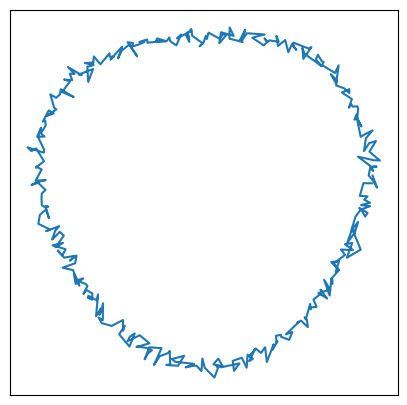

In [6]:
plot_constellation(train_coords, 0)

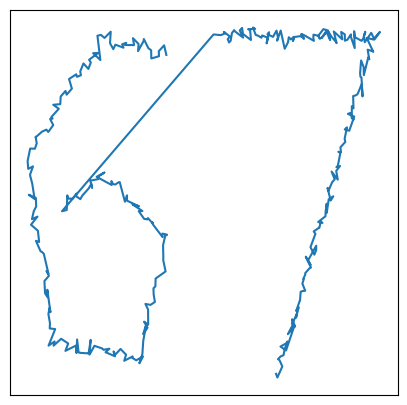

In [7]:
plot_constellation(test_coords, 0)

In [8]:
candidates['text'].map(lambda x: x in train['text']).sum()

np.int64(0)

In [9]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [10]:
from transformers import AutoTokenizer, AutoModel

model_name = 'google-bert/bert-base-uncased'
MAX_LENGTH = 128

def load_tokenizer_and_model(model_name):
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModel.from_pretrained(model_name).to(device)
    return tokenizer, model

def encode_batch(model, tokenizer, texts, device, batch_size=32):
    model.eval()
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc='Batch'):
        batch = texts[i:i+batch_size]
        enc = tokenizer(
            batch,
            max_length=MAX_LENGTH,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            out = model(**enc)
        embs = out['last_hidden_state'][:, 0, :]
        embeddings.append(embs)
    embeddings = torch.cat(embeddings)
    return embeddings

In [11]:
tokenizer, model = load_tokenizer_and_model(model_name)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: google-bert/bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [12]:
unique_train_texts = sorted(train['text'].unique().tolist())
train_text2id = {v: i for i, v in enumerate(unique_train_texts)}
train_id2text = {v: k for k, v in train_text2id.items()}
len(unique_train_texts)

300

In [13]:
train_embeddings = encode_batch(model, tokenizer, unique_train_texts, device)
train_embeddings.shape

Batch:   0%|          | 0/10 [00:00<?, ?it/s]

torch.Size([300, 768])

In [14]:
cand_texts = candidates['text'].tolist()
cand_text2id = {v: i for i, v in enumerate(cand_texts)}
cand_id2text = {v: k for k, v in cand_text2id.items()}

In [15]:
cand_embeddings = encode_batch(model, tokenizer, cand_texts, device)
cand_embeddings.shape

Batch:   0%|          | 0/16 [00:00<?, ?it/s]

torch.Size([500, 768])

In [16]:
train_text_ids = train['text'].map(train_text2id.get).tolist()
cand_text_ids = candidates['text'].map(cand_text2id.get).tolist()
len(train_text_ids), len(cand_text_ids)

(15715, 500)

In [17]:
from sklearn.model_selection import train_test_split 

train_coords, valid_coords, train_text_ids, valid_text_ids = train_test_split(
    train_coords, train_text_ids, test_size=0.1, stratify=train_text_ids, random_state=42
)

train_coords.shape, valid_coords.shape, len(train_text_ids), len(valid_text_ids)

((14143, 2, 364), (1572, 2, 364), 14143, 1572)

In [18]:
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import v2

def fig2pil(fig):
    buf = io.BytesIO()
    fig.savefig(
        buf,
        format='png',
        pad_inches=0,
    )
    buf.seek(0)
    img = Image.open(buf).convert('RGB')
    return img

def coords2fig(coords, i):
    fig = plt.figure(figsize=(2.56, 2.56), dpi=100)
    ax = fig.add_axes([0, 0, 1, 1])

    ax.plot(coords[i][0], coords[i][1])

    ax.set_xticks([])
    ax.set_yticks([])

    ax.axis('off')

    x, y = coords[i]
    ax.set_xlim(min(x), max(x))
    ax.set_ylim(min(y), max(y))

    plt.close(fig)
    
    return fig

class SherrifDataset(Dataset):
    def __init__(self, coords, embeddings=None, text_ids=None, transform=None):
        self.coords = coords
        self.embeddings = embeddings
        self.text_ids = text_ids
        self.transform = transform

    def __len__(self):
        return len(self.coords)

    def __getitem__(self, idx):
        img = fig2pil(coords2fig(self.coords, idx))
        if self.transform is not None:
            img = self.transform(img)

        if self.embeddings is None or self.text_ids is None:
            return img
        
        emb = self.embeddings[self.text_ids[idx]]
        return img, emb

train_transform = v2.Compose([
    v2.ToTensor()
])

test_transform = v2.Compose([
    v2.ToTensor()
])

train_ds = SherrifDataset(train_coords, train_embeddings, train_text_ids, train_transform)
valid_ds = SherrifDataset(valid_coords, train_embeddings, valid_text_ids, test_transform)
test_ds = SherrifDataset(test_coords, transform=test_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=32, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)

len(train_loader), len(valid_loader), len(test_loader)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


(442, 50, 82)

In [19]:
class SheriffModel(nn.Module):
    def __init__(self, in_channels=3, image_dim=256, out_features=768):
        super().__init__()

        self.conv1 = self.conv_block(in_channels, 16, kernel_size=11, padding=5)
        self.conv2 = self.conv_block(16, 64, kernel_size=9, padding=4)

        self.fc = nn.Sequential(
            nn.Linear(64 * (image_dim//16)**2, 1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(1024, out_features)
        )

        self.flatten = nn.Flatten()

    def conv_block(self, in_channels, out_channels, kernel_size=3, padding=1):
        return nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=kernel_size, padding=padding),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(out_channels),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(out_channels, out_channels, kernel_size=kernel_size, padding=padding),
            nn.ReLU(inplace=True),
            nn.BatchNorm2d(out_channels),
            nn.MaxPool2d(2, 2)
        )

    def forward(self, x):
        x = self.conv1(x) # [B, 64, 64]
        x = self.conv2(x) # [B, 16, 16]
        return self.fc(self.flatten(x)) # [B, out_features]

model = SheriffModel().to(device)

In [20]:
epochs = 3

criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, epochs*len(train_loader))

In [21]:
def fit_one_epoch(model, criterion, optimizer, scheduler, train_loader, device):
    model.train()
    rloss, i = 0, 0
    for X, y in (pbar := tqdm(train_loader, desc='Train Loader', leave=False)):
        X, y = X.to(device), y.to(device)
        out = model(X)
        loss = criterion(out, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        scheduler.step()

        i += 1
        rloss += loss.item()
        pbar.set_postfix({'loss': f'{rloss/i:.6f}', 'lr': f'{scheduler.get_last_lr()[0]:.8f}'})

    return rloss / i

def validate_one_epoch(model, criterion, valid_loader, device):
    model.eval()
    rloss, i = 0, 0
    for X, y in (pbar := tqdm(valid_loader, desc='Valid Loader', leave=False)):
        X, y = X.to(device), y.to(device)
        with torch.no_grad():
            out = model(X)
            loss = criterion(out, y)

        i += 1
        rloss += loss.item()
        pbar.set_postfix({'loss': f'{rloss/i:.6f}'})

    return rloss / i

def plot_history(history):
    clear_output()
    plt.figure(figsize=(10, 7))
    plt.plot(history['train_loss'], label='train')
    plt.plot(history['valid_loss'], label='valid')
    plt.legend()
    plt.show()

def fit(model, criterion, optimizer, scheduler, train_loader, valid_loader, device, epochs, history=None):
    if history is None:
        history = {
            'train_loss': [],
            'valid_loss': []
        }

    for epoch in tqdm(range(epochs), desc='Epoch'):
        tloss = fit_one_epoch(model, criterion, optimizer, scheduler, train_loader, device)
        vloss = validate_one_epoch(model, criterion, valid_loader, device)
        
        history['train_loss'].append(tloss)
        history['valid_loss'].append(vloss)

        plot_history(history)

    return history

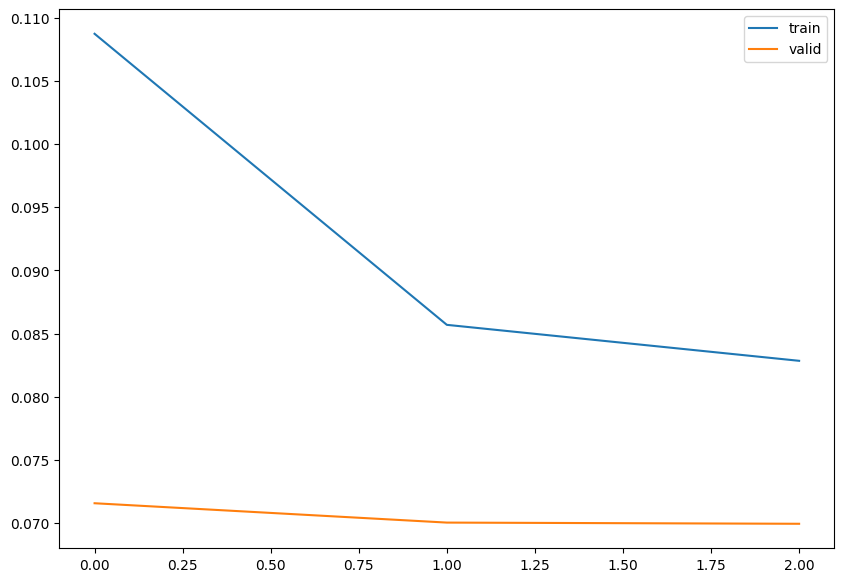

In [22]:
history = fit(model, criterion, optimizer, scheduler, train_loader, valid_loader, device, epochs)

In [24]:
test_pred_embeddings = []

for X in tqdm(test_loader, desc='Test Loader'):
    X = X.to(device)
    with torch.no_grad():
        out = model(X)
    test_pred_embeddings.append(out.cpu())

test_pred_embeddings = torch.cat(test_pred_embeddings)
test_pred_embeddings.shape

Test Loader:   0%|          | 0/82 [00:00<?, ?it/s]

torch.Size([2621, 768])

In [38]:
test_constellation_embeddings = torch.zeros(50, 768)
test_constellation_vc = torch.tensor(test['datapointID'].value_counts().sort_index().values)

cur = 0

for i in range(50):
    test_constellation_embeddings[i] = test_pred_embeddings[cur:cur+test_constellation_vc[i]].mean(dim=0)
    cur += test_constellation_vc[i]

test_constellation_embeddings

tensor([[ 0.0107, -0.0412, -0.1856,  ..., -0.0652,  0.2867,  0.4371],
        [ 0.0159, -0.0365, -0.1950,  ..., -0.1113,  0.3115,  0.3978],
        [ 0.0350, -0.0779, -0.2040,  ..., -0.0644,  0.3038,  0.4763],
        ...,
        [ 0.0673, -0.0470, -0.2195,  ..., -0.0850,  0.3455,  0.5193],
        [ 0.0876, -0.0513, -0.1925,  ..., -0.0764,  0.2977,  0.5013],
        [ 0.0552, -0.0275, -0.1881,  ..., -0.0625,  0.3180,  0.4624]])

In [44]:
test_constellation_embeddings_norm = F.normalize(test_constellation_embeddings)
cand_embeddings_norm = F.normalize(cand_embeddings.cpu())

cost_matrix = torch.matmul(test_constellation_embeddings_norm, cand_embeddings_norm.T)
cost_matrix.shape

torch.Size([50, 500])

In [56]:
from scipy.optimize import linear_sum_assignment

_, indices = linear_sum_assignment(cost_matrix, maximize=True)
indices

array([145, 413, 102, 446,  99,  59, 133, 449, 280, 326, 156, 379, 183,
       361, 494, 205, 196, 351, 109, 197, 478, 252, 300, 432, 309, 291,
       215, 462, 253, 421, 428, 212,  39, 241,  29, 437, 424, 429, 209,
       217, 118, 401, 141, 329,  50,  74,   0, 116, 259, 100])

In [57]:
subm = pd.DataFrame({
    'subtaskID': 1,
    'datapointID': range(1, 50+1),
    'answer': indices
})

subm.to_csv("submission.csv", index=False)

subm

,subtaskID,datapointID,answer
0,1,1,145
1,1,2,413
2,1,3,102
3,1,4,446
4,1,5,99
5,1,6,59
6,1,7,133
7,1,8,449
8,1,9,280
9,1,10,326
